# 7. Advanced EDA : Trends & Deep Dives <a id="7-advanced-eda" name="7-advanced-eda"></a>

TOP 10 FILMS — IMDb-style Weighted Rating:


,title,release_year,primary_genre,vote_average,vote_count,weighted_rating,director
1,The Shawshank Redemption,1994,Drama,8.72,30151,8.54,Frank Darabont
2,The Godfather,1972,Drama,8.69,22778,8.46,Francis Ford Coppola
3,The Dark Knight,2008,Action,8.53,35532,8.39,Christopher Nolan
4,Pulp Fiction,1994,Thriller,8.48,30025,8.33,Quentin Tarantino
5,The Lord of the Rings: The Return of the King,2003,Adventure,8.50,26353,8.32,Peter Jackson
6,Forrest Gump,1994,Comedy,8.46,29561,8.30,Robert Zemeckis
7,Schindler's List,1993,Drama,8.57,17336,8.30,Steven Spielberg
8,Fight Club,1999,Drama,8.44,31827,8.29,David Fincher
9,Spirited Away,2001,Animation,8.53,18183,8.28,Hayao Miyazaki
10,Parasite,2019,Comedy,8.49,20455,8.27,Bong Joon Ho


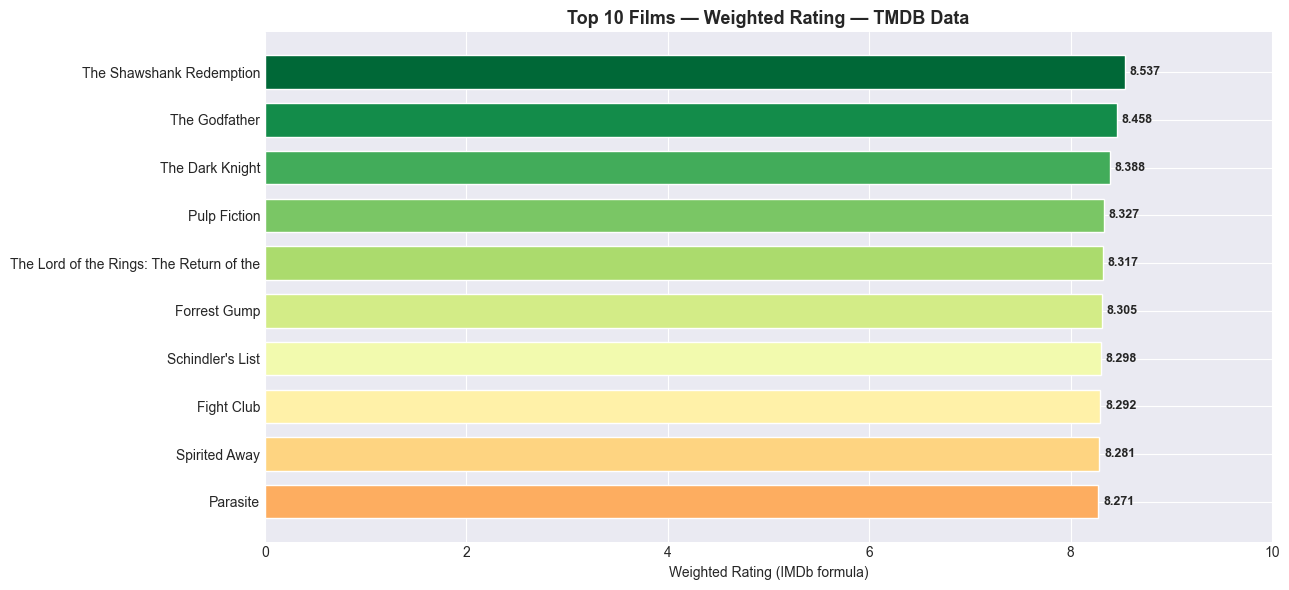

In [ ]:
# Top 10 movies by weighted rating
top10 = df.nlargest(10, "weighted_rating")[
    ["title","release_year","primary_genre","vote_average","vote_count","weighted_rating","director"]]
top10 = top10.reset_index(drop=True)
top10.index += 1
print("TOP 10 FILMS — IMDb-style Weighted Rating:")
display(top10)

fig, ax = plt.subplots(figsize=(13, 6))
colors_t = plt.cm.RdYlGn(np.linspace(0.3, 1.0, 10))
bars = ax.barh(top10["title"].str[:40], top10["weighted_rating"],
               color=colors_t[::-1], edgecolor="white", height=0.7)
ax.set_xlabel("Weighted Rating (IMDb formula)")
ax.set_title("Top 10 Films — Weighted Rating — TMDB Data", fontsize=13, fontweight="bold")
ax.set_xlim(0, 10); ax.invert_yaxis()
for bar, val in zip(bars, top10["weighted_rating"]):
    ax.text(val+0.05, bar.get_y()+bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("../exports/fig_09_top10.png", dpi=150, bbox_inches="tight")
plt.show()

 TOP DIRECTORS (min 3 films, by avg rating):


,films,avg_rating,avg_votes,total_revenue,avg_popularity
director,,,,,
Tosca Musk,3,8.38,1691.33,0,4.95
Charlie Chaplin,5,8.19,2865.60,26500000,6.73
Sergio Leone,6,8.11,5105.00,79280118,10.65
Paul Dugdale,4,8.10,257.75,15,2.89
Akira Kurosawa,13,8.05,1328.31,135548320,6.00
Yasujirō Ozu,3,8.03,664.67,0,3.52
Kazuya Tsurumaki,3,8.02,1282.33,134567049,7.73
Isao Takahata,3,7.98,3222.33,25681898,3.32
Satoshi Kon,4,7.97,2113.25,2275632,7.33


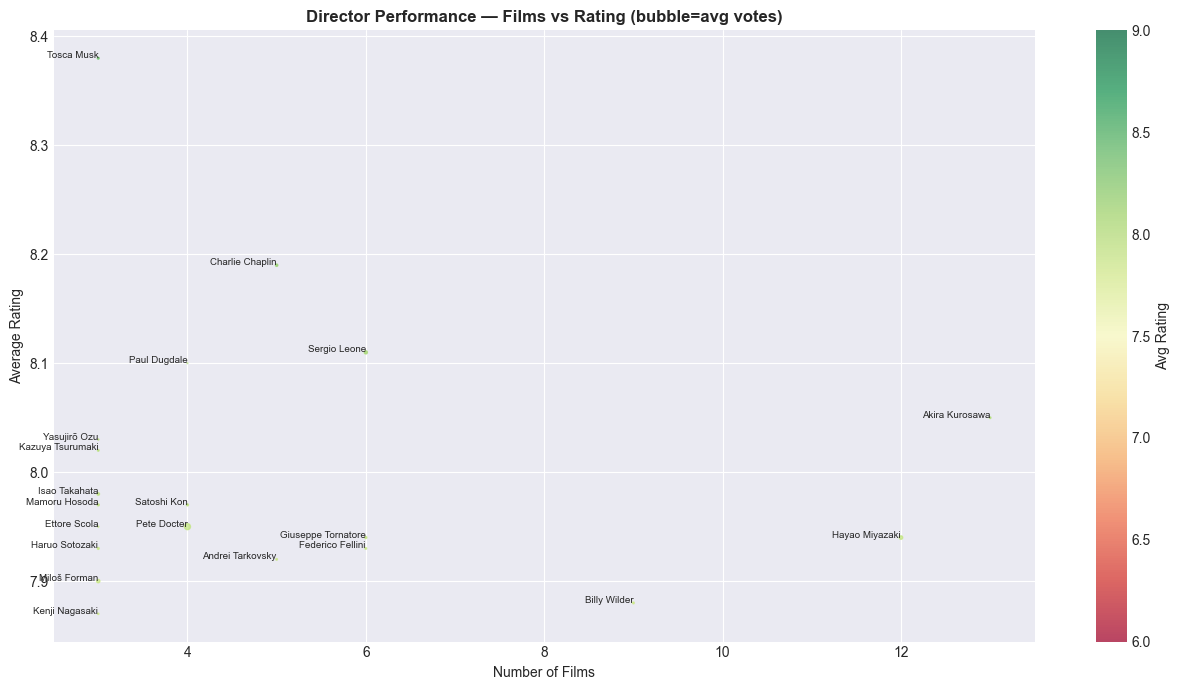

In [ ]:
# Director analysis
dir_stats = df.groupby("director").agg(
    films=("id","count"), avg_rating=("vote_average","mean"),
    avg_votes=("vote_count","mean"), total_revenue=("revenue","sum"),
    avg_popularity=("popularity","mean")
).round(2)
dir_stats = dir_stats[dir_stats["films"] >= 3].sort_values("avg_rating", ascending=False)

print(" TOP DIRECTORS (min 3 films, by avg rating):")
display(dir_stats.head(20))

fig, ax = plt.subplots(figsize=(13, 7))
top_d = dir_stats.head(20).reset_index()
scatter = ax.scatter(top_d["films"], top_d["avg_rating"],
    s=top_d["avg_votes"]/1000, alpha=0.7,
    c=top_d["avg_rating"], cmap="RdYlGn", vmin=6, vmax=9)
for _, row in top_d.iterrows():
    ax.annotate(row["director"], (row["films"], row["avg_rating"]), fontsize=7, ha="right")
plt.colorbar(scatter, ax=ax, label="Avg Rating")
ax.set_xlabel("Number of Films"); ax.set_ylabel("Average Rating")
ax.set_title("Director Performance — Films vs Rating (bubble=avg votes)", fontweight="bold")
plt.tight_layout()
plt.savefig("../exports/fig_10_directors.png", dpi=150, bbox_inches="tight")
plt.show()


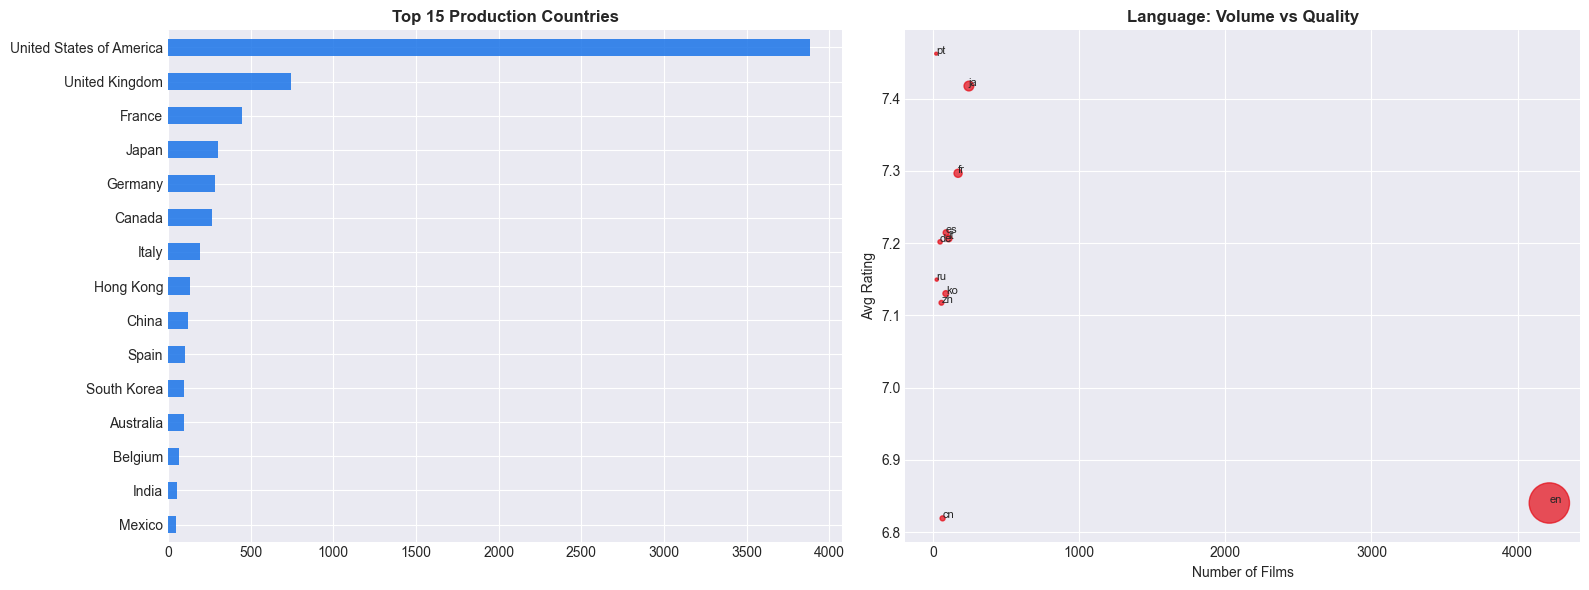

In [ ]:
# Production countries
ctry_list = []
for c in df["production_countries"].dropna():
    for x in str(c).split(","):
        x = x.strip()
        if x: ctry_list.append(x)
ctry_counts = pd.Series(ctry_list).value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ctry_counts.plot(kind="barh", ax=axes[0], color="#1a73e8", alpha=0.85)
axes[0].set_title("Top 15 Production Countries", fontweight="bold")
axes[0].invert_yaxis()

# Language vs rating scatter
lang_stats = df.groupby("original_language").agg(
    count=("id","count"), avg_rating=("vote_average","mean")).reset_index()
lang_stats = lang_stats[lang_stats["count"] >= 20]
axes[1].scatter(lang_stats["count"], lang_stats["avg_rating"],
    s=lang_stats["count"]/5, alpha=0.7, color="#e50914")
for _, row in lang_stats.iterrows():
    axes[1].annotate(row["original_language"], (row["count"], row["avg_rating"]), fontsize=8)
axes[1].set_xlabel("Number of Films"); axes[1].set_ylabel("Avg Rating")
axes[1].set_title("Language: Volume vs Quality", fontweight="bold")

plt.tight_layout()
plt.savefig("../exports/fig_11_countries_languages.png", dpi=150, bbox_inches="tight")
plt.show()
